In [ ]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score

In [2]:
# Load sparse matrix and labels
X = joblib.load("pkl/X_sparse.pkl")
y = joblib.load("pkl/y.pkl")

print("Shape X:", X.shape)
print("Shape y:", len(y))

Shape X: (1000, 79)
Shape y: 1000


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [4]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)


In [5]:
rf_f1_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=skf,
    scoring="f1",
    n_jobs=-1
)

print("RF CV F1:", rf_f1_scores)
print("Mean F1:", rf_f1_scores.mean())
print("Std:", rf_f1_scores.std())

RF CV F1: [0.95940959 0.95910781 0.95555556 0.95488722 0.95454545]
Mean F1: 0.9567011257867029
Std: 0.002115534188296499


In [6]:
rf_model.fit(X_train, y_train)

y_rf_pred = rf_model.predict(X_test)
y_rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [7]:
print("Random Forest Classification Report")
print(classification_report(y_test, y_rf_pred))

print("RF Test F1:", f1_score(y_test, y_rf_pred))


Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.92      0.58      0.71        38
           1       0.91      0.99      0.95       162

    accuracy                           0.91       200
   macro avg       0.91      0.78      0.83       200
weighted avg       0.91      0.91      0.90       200

RF Test F1: 0.9467455621301775


In [10]:
joblib.dump(rf_model, "pkl/random_forest_model.pkl")

print(" Random Forest model saved")

 Random Forest model saved


In [13]:
tfidf_skills = joblib.load("pkl/tfidf_skills.pkl")
tfidf_edu = joblib.load("pkl/tfidf_edu.pkl")
tfidf_cert = joblib.load("pkl/tfidf_cert.pkl")
tfidf_job = joblib.load("pkl/tfidf_job.pkl")

feature_names = (
    list(tfidf_skills.get_feature_names_out()) +
    list(tfidf_edu.get_feature_names_out()) +
    list(tfidf_cert.get_feature_names_out()) +
    list(tfidf_job.get_feature_names_out()) +
    ['Experience (Years)', 'Projects Count']
)

importances = rf_model.feature_importances_

indices = np.argsort(importances)[::-1]

for i in indices[:20]:
    print(feature_names[i], importances[i])

Experience (Years) 0.44627358450349036
Projects Count 0.16488038284147827
python 0.01457730080086175
cybersecurity 0.012754951307400345
sql 0.011332306506393532
networking 0.010029362814091235
learning 0.009299947583855427
mba 0.009227873138931055
phd 0.009161185751663312
linux 0.009108634078358798
tech 0.009051053774632813
react 0.008831692356318593
sc 0.008687014992171687
pytorch 0.008375843258657593
machine learning 0.0082952437404998
nlp 0.008245192857521367
tensorflow 0.008148282168429541
hacking 0.007919199901597273
machine 0.007662953235864127
ml 0.007378941388112175


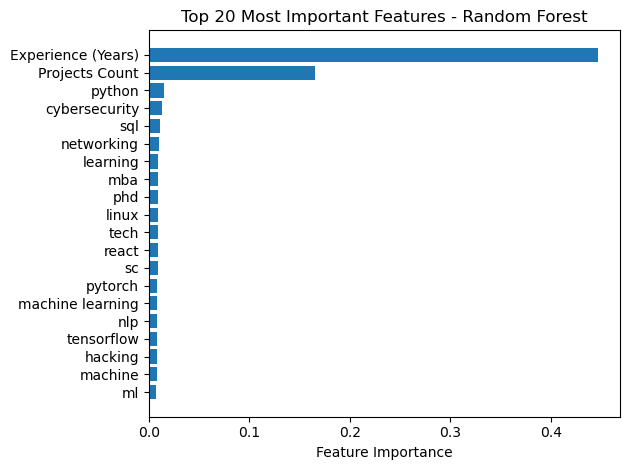

In [ ]:
# Lấy importance
importances = rf_model.feature_importances_

# Sắp xếp giảm dần
indices = np.argsort(importances)[::-1][:20]

top_features = [feature_names[i] for i in indices]
top_importances = importances[indices]

# Vẽ biểu đồ (1 chart duy nhất)
plt.figure()
plt.barh(top_features[::-1], top_importances[::-1])
plt.xlabel("Feature Importance")
plt.title("Top 20 Most Important Features - Random Forest")
plt.figsize=(8,10)
plt.tight_layout()
plt.show()